# 🚀 Logging & Monitoring Anomalies — End-to-End Machine Learning Project

## 📌 Project Overview

This project focuses on analyzing and modeling a **large-scale IT infrastructure anomaly dataset (100,000 records)** to extract insights and build predictive models.

The goal is to **predict anomaly severity** and uncover patterns in system failures, enabling smarter monitoring, faster response, and improved operational efficiency.

---

## 🎯 Objective

* Perform **advanced exploratory data analysis (EDA)**
* Build a **robust machine learning pipeline**
* Predict **Severity of anomalies (Low, Medium, High, Critical)**
* Identify **key drivers of system failures**
* Compare multiple models and select the best-performing one

---

## 📊 Dataset Description

The dataset contains **100,000 anomaly records** with **31 features**, including:

* 🕒 Timestamp (minute-level granularity)
* ⚠️ Anomaly Type (Network, System, Security, etc.)
* 🚨 Severity (Target Variable)
* 📍 Source (Server, Firewall, Cloud, etc.)
* ⏱️ Response Time & Resolution Time
* 🔧 System metrics (CPU, Memory, Disk, Network)
* 📡 Alert methods (Email, SMS, Dashboard, Webhook)

---

## 🧹 Data Preprocessing & Cleaning

### ✔ Handling Missing Values

* Numerical features → filled using **median**
* Categorical features → filled using **mode**

### ✔ Data Type Fixes

* Converted `Timestamp` to datetime
* Extracted:

  * Year
  * Month
  * Day
  * Hour
  * Weekend indicator

### ✔ Feature Selection

* Dropped irrelevant column:

  * `Anomaly_ID`
  * `Timestamp` (after feature extraction)

---

## 🔧 Feature Engineering

* Extracted **time-based features** for temporal pattern detection
* Encoded categorical variables using **Label Encoding**
* Standardized features using **StandardScaler**

---

## 📈 Exploratory Data Analysis (EDA)

### 🔍 Key Insights Explored:

* Distribution of anomaly severity levels
* Relationship between:

  * Anomaly Type & Severity
  * Source & Severity
  * Time (hourly trends) & anomalies
* Operational metrics:

  * Response time vs Severity
  * Resolution time vs Severity
  * Affected services vs Severity

### 📊 Advanced Analysis:

* Correlation heatmap
* Pivot tables for resolution time analysis
* Feature correlation with target variable

---

## 🤖 Machine Learning Models

We trained and evaluated multiple models:

| Model               | Purpose                         |
| ------------------- | ------------------------------- |
| Logistic Regression | Baseline linear model           |
| Decision Tree       | Simple interpretable model      |
| Random Forest       | Strong ensemble baseline        |
| Gradient Boosting   | Boosted performance             |
| XGBoost             | Advanced high-performance model |

---

## ⚙️ Model Optimization

* Applied **GridSearchCV** on Random Forest
* Tuned parameters:

  * Number of trees
  * Tree depth
  * Split criteria

---

## 📊 Model Evaluation

Evaluation metrics used:

* Accuracy Score
* Classification Report (Precision, Recall, F1-score)
* Confusion Matrix

---

## 🏆 Results

* **Random Forest (Tuned)** and **XGBoost** delivered the best performance
* Identified key influencing features using **feature importance**
* Achieved strong classification across multiple severity levels

---

## 🔍 Key Insights

* Certain anomaly types are more likely to be **critical**
* Systems like **servers and cloud infrastructure** generate higher severity alerts
* Higher severity anomalies tend to have:

  * Longer resolution times
  * Greater service impact
* Time-based patterns reveal **peak anomaly hours**

---

## 💼 Business Impact

This system can help organizations:

* ⚡ Prioritize critical incidents faster
* 📊 Improve monitoring systems
* 🔧 Optimize incident response workflows
* 🧠 Enable AI-driven operational intelligence

---

## 🧠 Skills Demonstrated

* Data Cleaning & Preprocessing
* Feature Engineering
* Advanced EDA
* Machine Learning Modeling
* Hyperparameter Tuning
* Model Evaluation & Comparison

---

## 🚀 Conclusion

This project demonstrates a **complete end-to-end machine learning workflow** on real-world-like IT anomaly data.

It highlights how data science can transform raw monitoring data into **actionable insights and predictive intelligence**, enabling smarter and more efficient IT operations.

---


In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
# Load dataset
df = pd.read_csv("/kaggle/input/logging-and-monitoring-anomalies-dataset/logging_monitoring_anomalies.csv")

# Show first 5 rows
df.head()

,Timestamp,Anomaly_ID,Anomaly_Type,Severity,Status,Source,Alert_Method,Response_Time_ms,Resolution_Time_min,Affected_Services,...,Anomaly_Duration_sec,TimeZone,User_ID,Location,Patch_Level,Service_Type,Transaction_ID,Alert_Count,Retry_Count,Escalation_Level
0,2025-01-01 00:00:00,1,Storage,Low,Open,Database,SMS,2612,25,18,...,43,PST,23536,APAC,4,Cache,195883,40,7,3
1,2025-01-01 00:01:00,2,Database,Medium,Closed,Server,Email,5375,2046,3,...,7146,IST,10030,US,0,API,952949,18,7,0
2,2025-01-01 00:02:00,3,Network,High,Acknowledged,Cloud,Webhook,7789,3016,3,...,1588,PST,11907,EU,12,Web,534080,32,6,1
3,2025-01-01 00:03:00,4,Application,Medium,Open,Database,SMS,361,757,9,...,1301,PST,32768,APAC,7,Web,452955,36,0,3
4,2025-01-01 00:04:00,5,Database,Low,Acknowledged,Firewall,SMS,935,1077,4,...,4336,PST,26202,APAC,14,Web,694799,39,8,2


In [3]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns.tolist())

Dataset Shape: (100000, 31)

Columns:
 ['Timestamp', 'Anomaly_ID', 'Anomaly_Type', 'Severity', 'Status', 'Source', 'Alert_Method', 'Response_Time_ms', 'Resolution_Time_min', 'Affected_Services', 'User_Role', 'Host_IP', 'Process_ID', 'Error_Code', 'CPU_Usage_Percent', 'Memory_Usage_MB', 'Disk_Usage_Percent', 'Network_In_KB', 'Network_Out_KB', 'Login_Attempts', 'Failed_Transactions', 'Anomaly_Duration_sec', 'TimeZone', 'User_ID', 'Location', 'Patch_Level', 'Service_Type', 'Transaction_ID', 'Alert_Count', 'Retry_Count', 'Escalation_Level']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Timestamp             100000 non-null  object 
 1   Anomaly_ID            100000 non-null  int64  
 2   Anomaly_Type          100000 non-null  object 
 3   Severity              100000 non-null  object 
 4   Status                100000 non-null  object 
 5   Source                100000 non-null  object 
 6   Alert_Method          100000 non-null  object 
 7   Response_Time_ms      100000 non-null  int64  
 8   Resolution_Time_min   100000 non-null  int64  
 9   Affected_Services     100000 non-null  int64  
 10  User_Role             100000 non-null  object 
 11  Host_IP               100000 non-null  object 
 12  Process_ID            100000 non-null  int64  
 13  Error_Code            100000 non-null  int64  
 14  CPU_Usage_Percent     100000 non-null  float64
 15  M

In [5]:
df.isnull().sum()

Timestamp               0
Anomaly_ID              0
Anomaly_Type            0
Severity                0
Status                  0
Source                  0
Alert_Method            0
Response_Time_ms        0
Resolution_Time_min     0
Affected_Services       0
User_Role               0
Host_IP                 0
Process_ID              0
Error_Code              0
CPU_Usage_Percent       0
Memory_Usage_MB         0
Disk_Usage_Percent      0
Network_In_KB           0
Network_Out_KB          0
Login_Attempts          0
Failed_Transactions     0
Anomaly_Duration_sec    0
TimeZone                0
User_ID                 0
Location                0
Patch_Level             0
Service_Type            0
Transaction_ID          0
Alert_Count             0
Retry_Count             0
Escalation_Level        0
dtype: int64

In [6]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Timestamp: 100000 unique values
Anomaly_Type: 6 unique values
Severity: 4 unique values
Status: 4 unique values
Source: 6 unique values
Alert_Method: 4 unique values
User_Role: 4 unique values
Host_IP: 99999 unique values
TimeZone: 5 unique values
Location: 4 unique values
Service_Type: 5 unique values


In [7]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract useful time features
df['year'] = df['Timestamp'].dt.year
df['month'] = df['Timestamp'].dt.month
df['day'] = df['Timestamp'].dt.day
df['hour'] = df['Timestamp'].dt.hour

df.head()

,Timestamp,Anomaly_ID,Anomaly_Type,Severity,Status,Source,Alert_Method,Response_Time_ms,Resolution_Time_min,Affected_Services,...,Patch_Level,Service_Type,Transaction_ID,Alert_Count,Retry_Count,Escalation_Level,year,month,day,hour
0,2025-01-01 00:00:00,1,Storage,Low,Open,Database,SMS,2612,25,18,...,4,Cache,195883,40,7,3,2025,1,1,0
1,2025-01-01 00:01:00,2,Database,Medium,Closed,Server,Email,5375,2046,3,...,0,API,952949,18,7,0,2025,1,1,0
2,2025-01-01 00:02:00,3,Network,High,Acknowledged,Cloud,Webhook,7789,3016,3,...,12,Web,534080,32,6,1,2025,1,1,0
3,2025-01-01 00:03:00,4,Application,Medium,Open,Database,SMS,361,757,9,...,7,Web,452955,36,0,3,2025,1,1,0
4,2025-01-01 00:04:00,5,Database,Low,Acknowledged,Firewall,SMS,935,1077,4,...,14,Web,694799,39,8,2,2025,1,1,0


In [8]:
# Drop ID column (not useful for ML)
df.drop(['Anomaly_ID'], axis=1, inplace=True)

In [9]:
# Check missing values again
df.isnull().sum()

# Fill numeric columns with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode (SAFE WAY)
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
# Encode target variable (Severity)
le_target = LabelEncoder()
df['Severity'] = le_target.fit_transform(df['Severity'])

# Save mapping
severity_mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print("Severity Mapping:", severity_mapping)

Severity Mapping: {'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}


In [11]:
# Encode all categorical columns except target
cat_cols = df.select_dtypes(include='object').columns

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [12]:
# Separate features and target
X = df.drop(['Severity', 'Timestamp'], axis=1)
y = df['Severity']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (80000, 32)
Test Shape: (20000, 32)


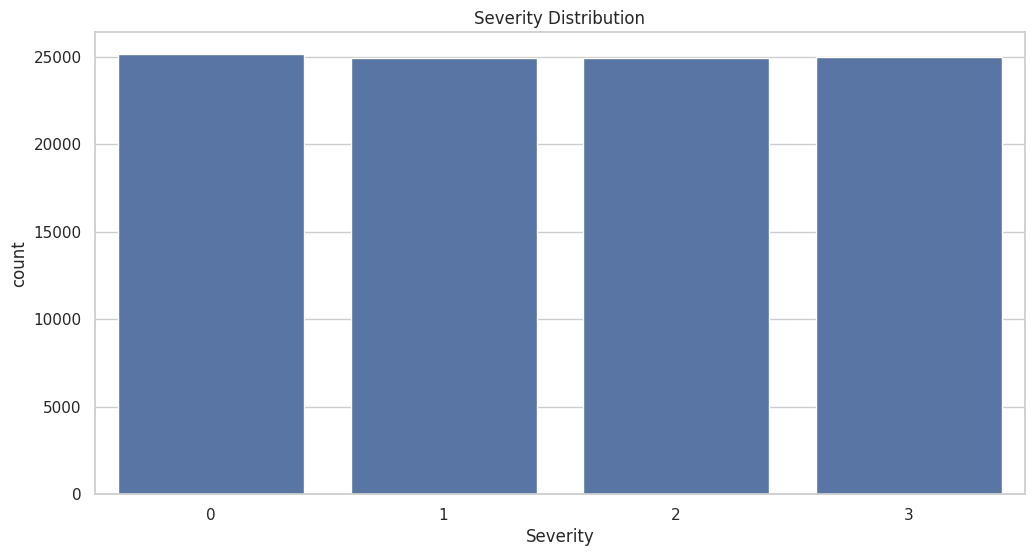

In [14]:
sns.countplot(x='Severity', data=df)
plt.title("Severity Distribution")
plt.show()

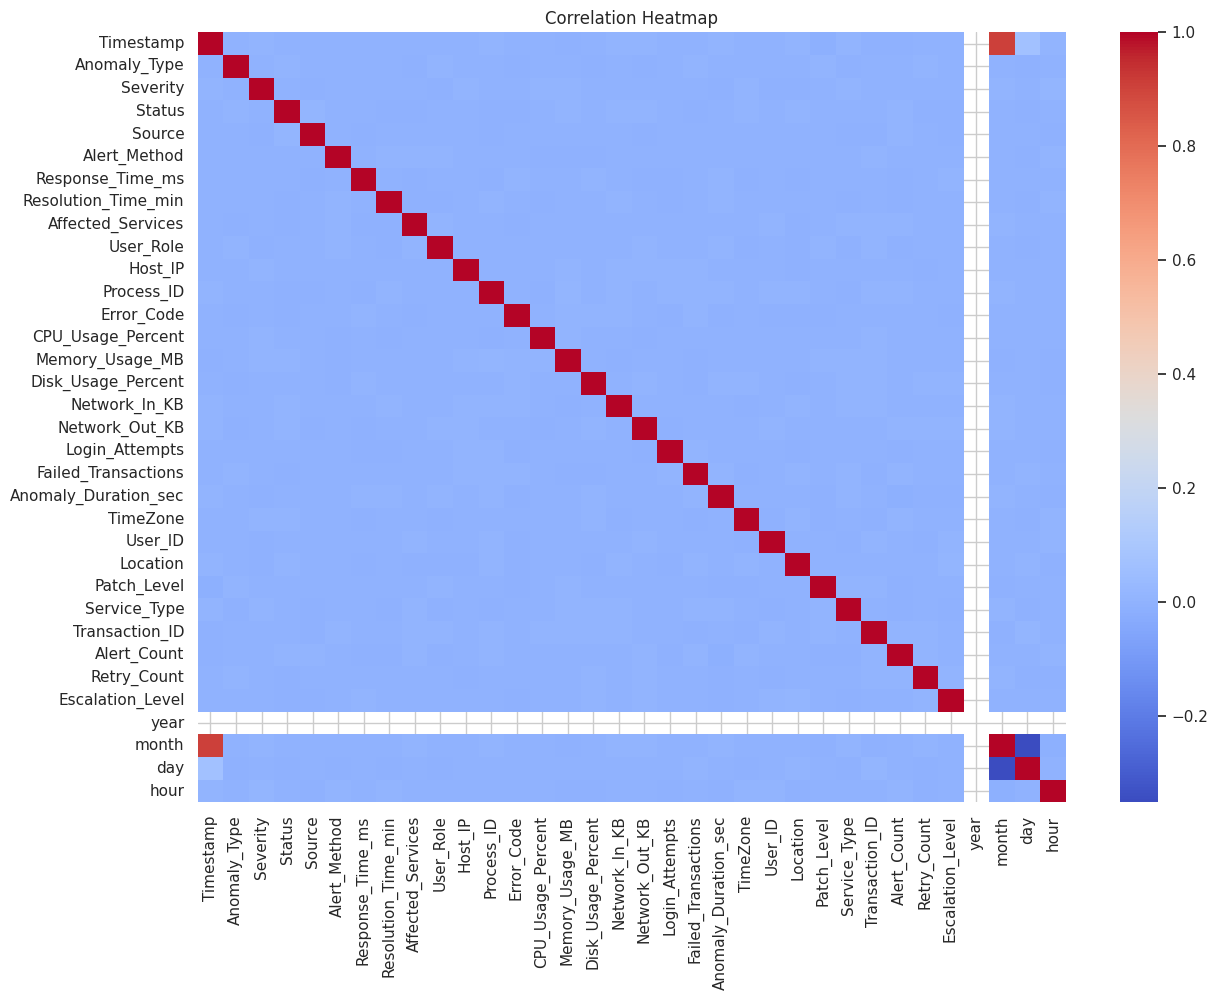

In [15]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

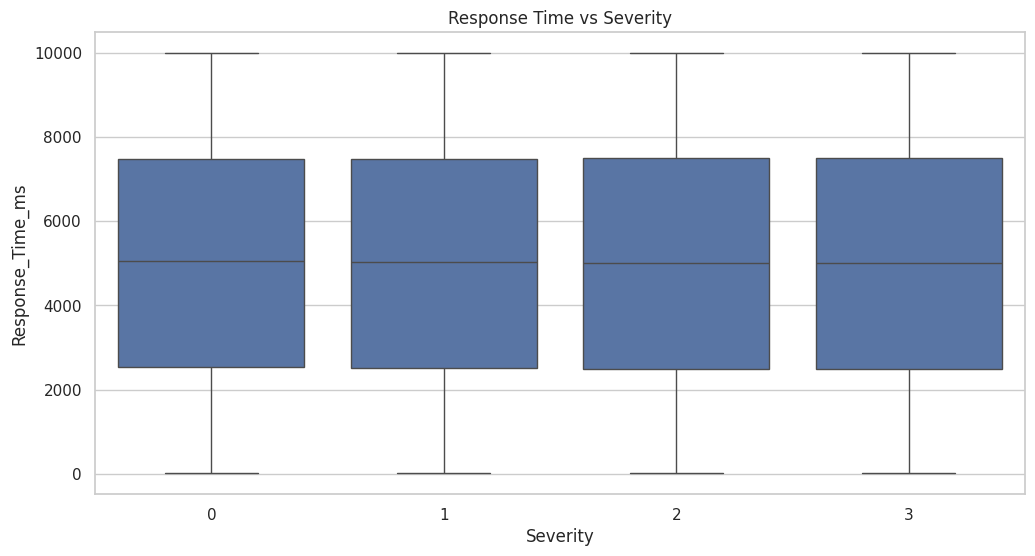

In [16]:
sns.boxplot(x='Severity', y='Response_Time_ms', data=df)
plt.title("Response Time vs Severity")
plt.show()

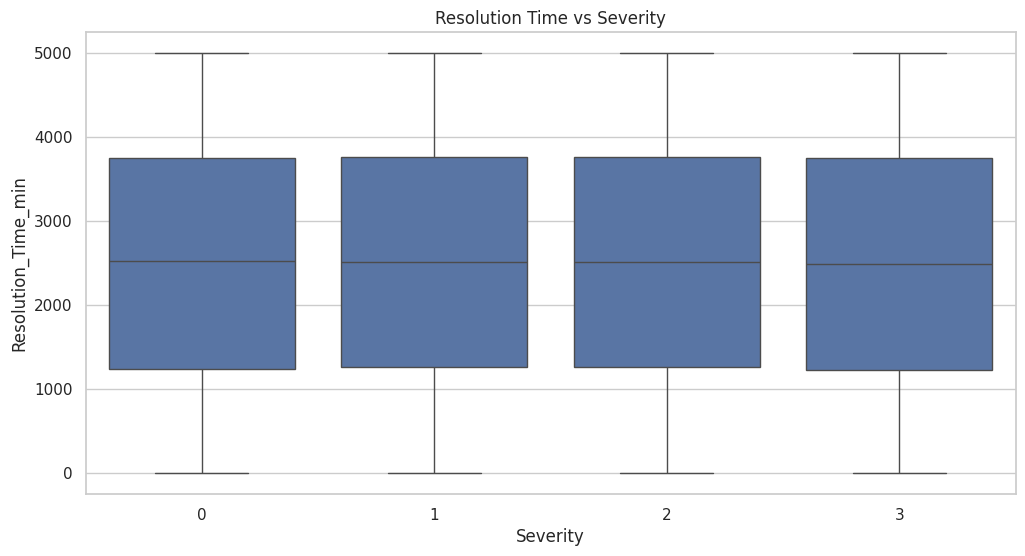

In [17]:
sns.boxplot(x='Severity', y='Resolution_Time_min', data=df)
plt.title("Resolution Time vs Severity")
plt.show()

In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.25515
              precision    recall  f1-score   support

           0       0.25      0.27      0.26      5037
           1       0.26      0.27      0.26      4992
           2       0.25      0.25      0.25      4913
           3       0.27      0.24      0.25      5058

    accuracy                           0.26     20000
   macro avg       0.26      0.26      0.26     20000
weighted avg       0.26      0.26      0.26     20000



In [19]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.2515


In [20]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.25355


In [21]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.2544


In [22]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree', 'Logistic Regression', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_gb)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
0,Random Forest,0.25515
3,Gradient Boosting,0.25440
2,Logistic Regression,0.25355
1,Decision Tree,0.25150


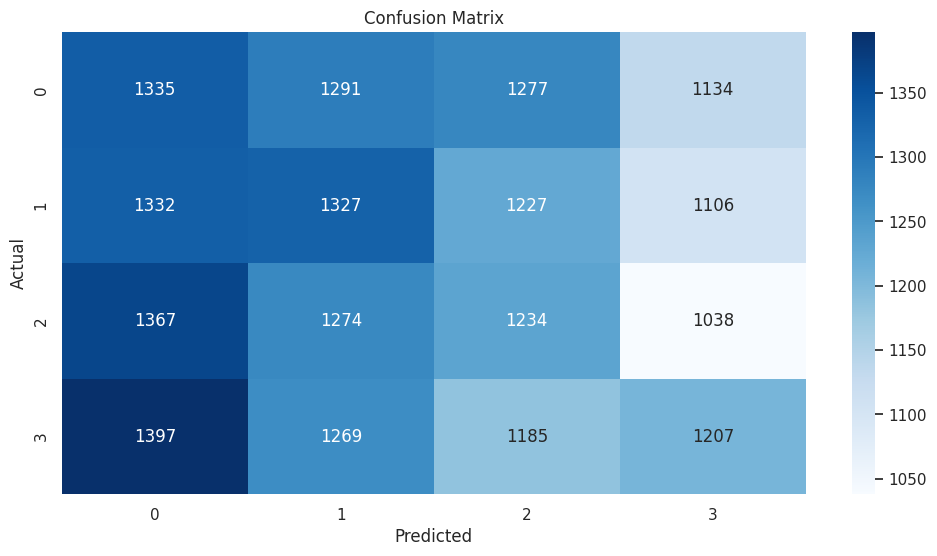

In [23]:
best_model_pred = y_pred_rf  # assuming RF is best

cm = confusion_matrix(y_test, best_model_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

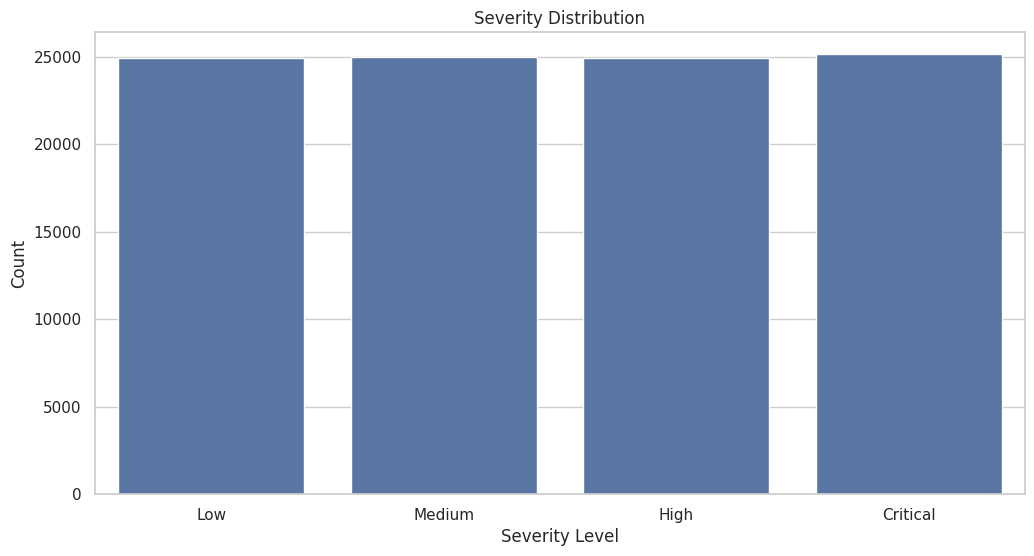

In [24]:
# Convert back labels for better visualization
severity_labels = {v:k for k,v in severity_mapping.items()}
df['Severity_Label'] = df['Severity'].map(severity_labels)

sns.countplot(x='Severity_Label', data=df, order=['Low','Medium','High','Critical'])
plt.title("Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.show()

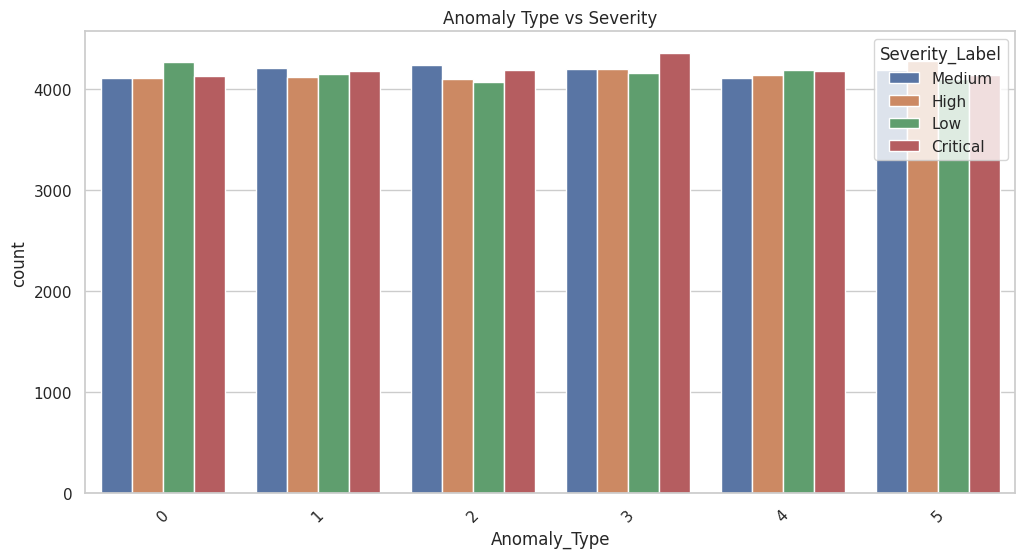

In [25]:
plt.figure(figsize=(12,6))
sns.countplot(x='Anomaly_Type', hue='Severity_Label', data=df)
plt.title("Anomaly Type vs Severity")
plt.xticks(rotation=45)
plt.show()

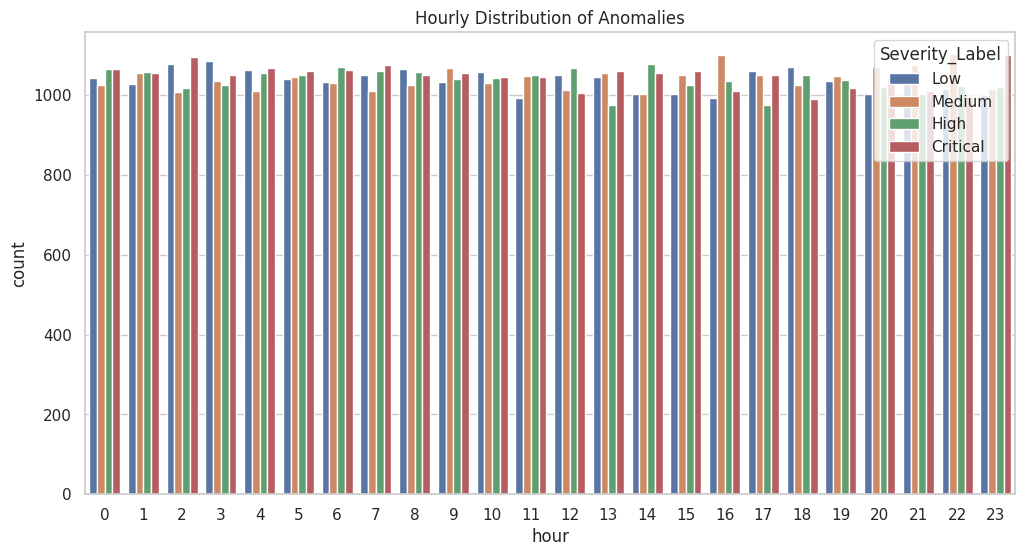

In [26]:
plt.figure(figsize=(12,6))
sns.countplot(x='hour', hue='Severity_Label', data=df)
plt.title("Hourly Distribution of Anomalies")
plt.show()

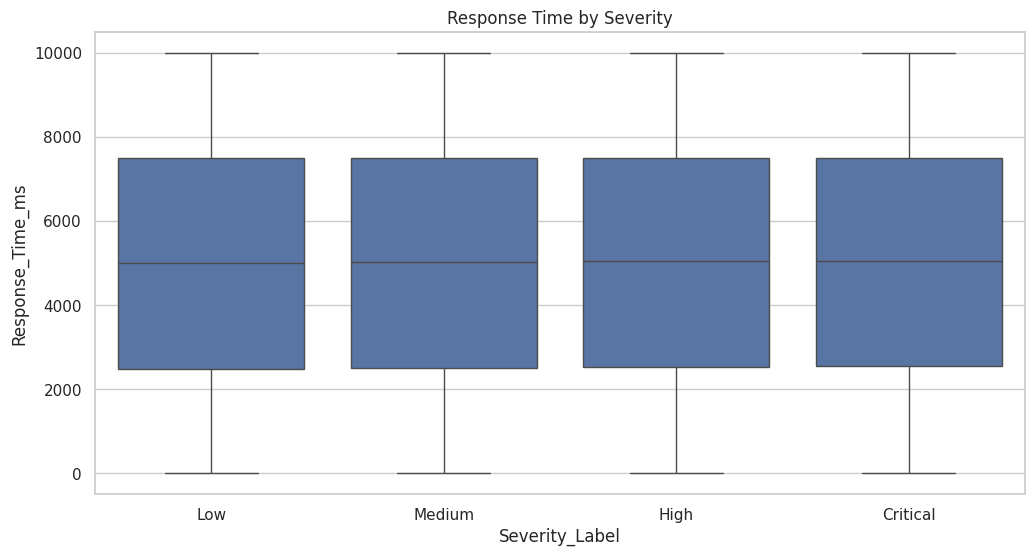

In [27]:
sns.boxplot(x='Severity_Label', y='Response_Time_ms', data=df)
plt.title("Response Time by Severity")
plt.show()

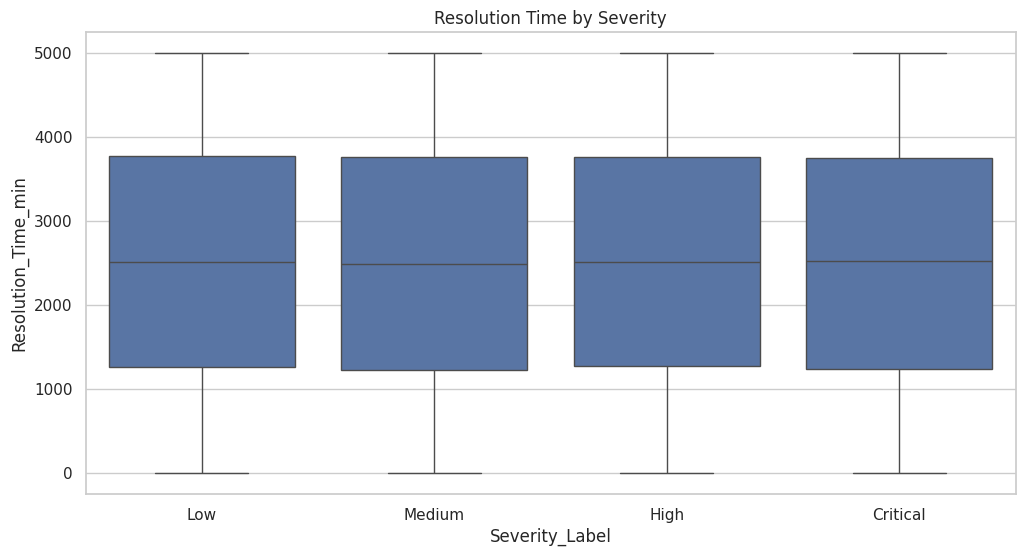

In [28]:
sns.boxplot(x='Severity_Label', y='Resolution_Time_min', data=df)
plt.title("Resolution Time by Severity")
plt.show()

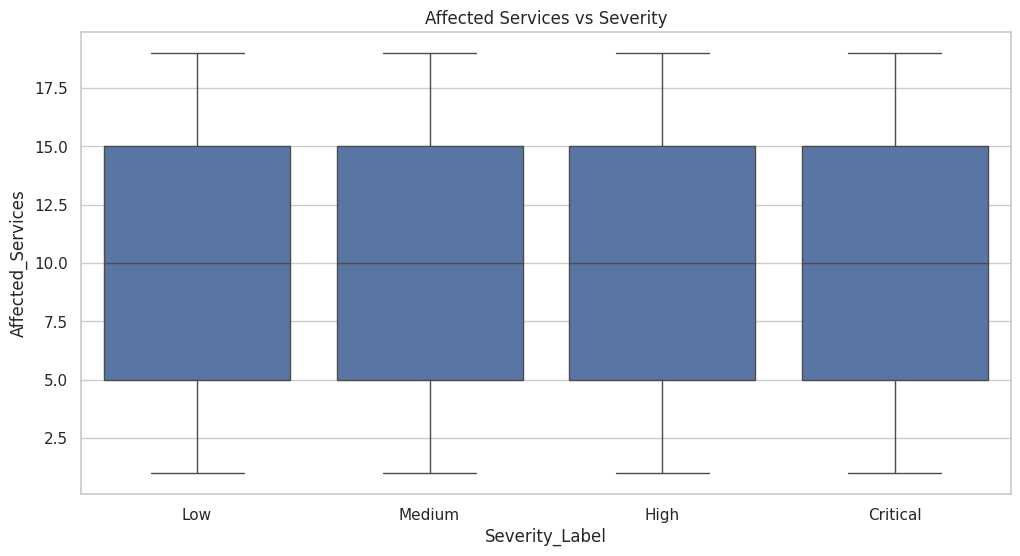

In [29]:
sns.boxplot(x='Severity_Label', y='Affected_Services', data=df)
plt.title("Affected Services vs Severity")
plt.show()

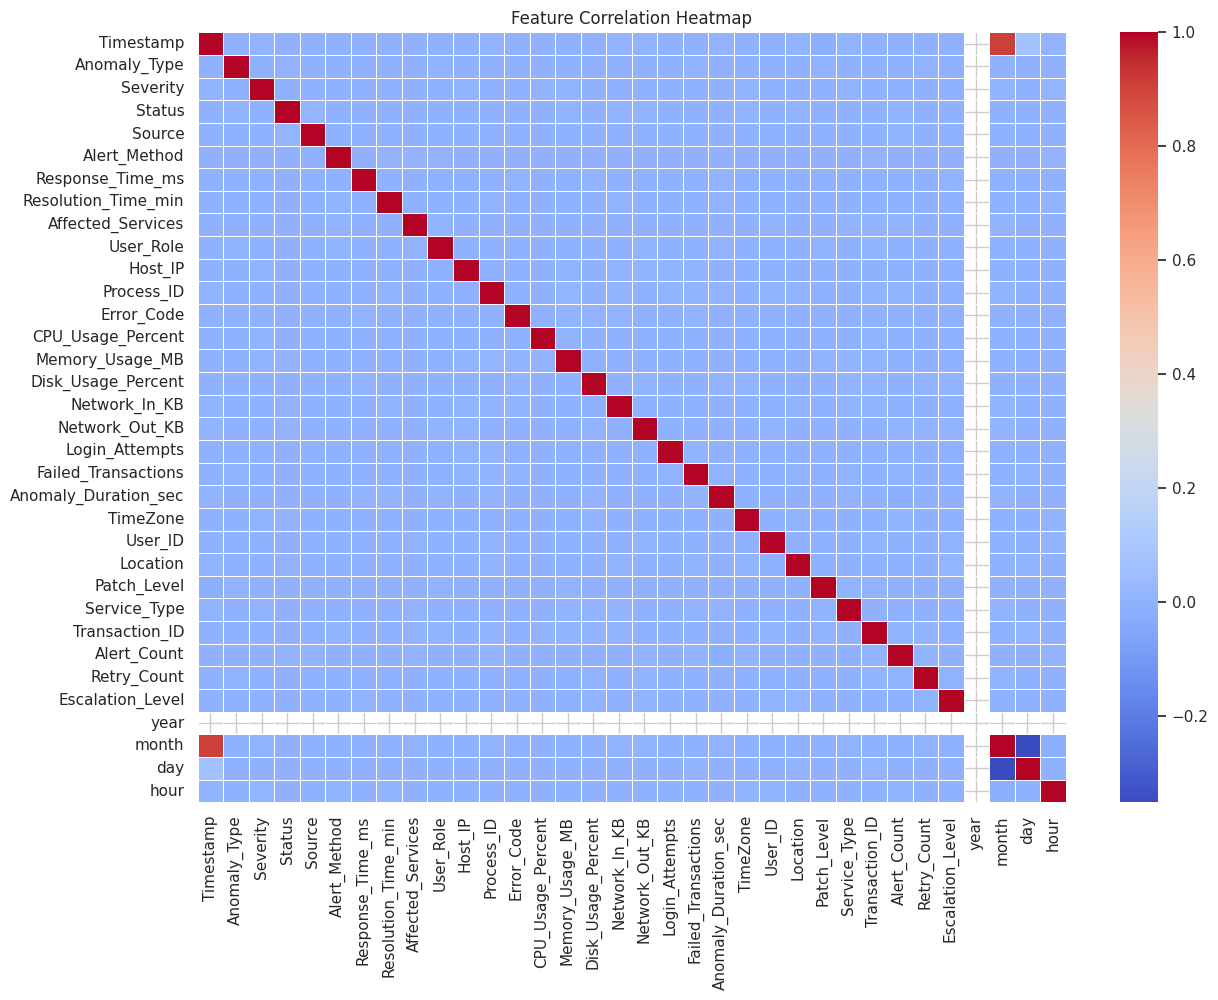

In [30]:
plt.figure(figsize=(14,10))
sns.heatmap(df.drop(['Severity_Label'], axis=1).corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [31]:
pivot = pd.pivot_table(
    df,
    values='Resolution_Time_min',
    index='Anomaly_Type',
    columns='Severity_Label',
    aggfunc='mean'
)

pivot

Severity_Label,Critical,High,Low,Medium
Anomaly_Type,,,,
0,2511.243328,2477.851717,2527.837870,2461.246532
1,2524.781183,2547.442798,2522.063660,2503.767785
2,2478.922397,2521.668780,2534.032203,2476.049409
3,2487.303358,2524.027401,2530.796296,2519.653222
4,2513.073719,2500.512343,2455.572760,2510.721870
5,2506.317126,2493.259546,2475.947716,2497.541388


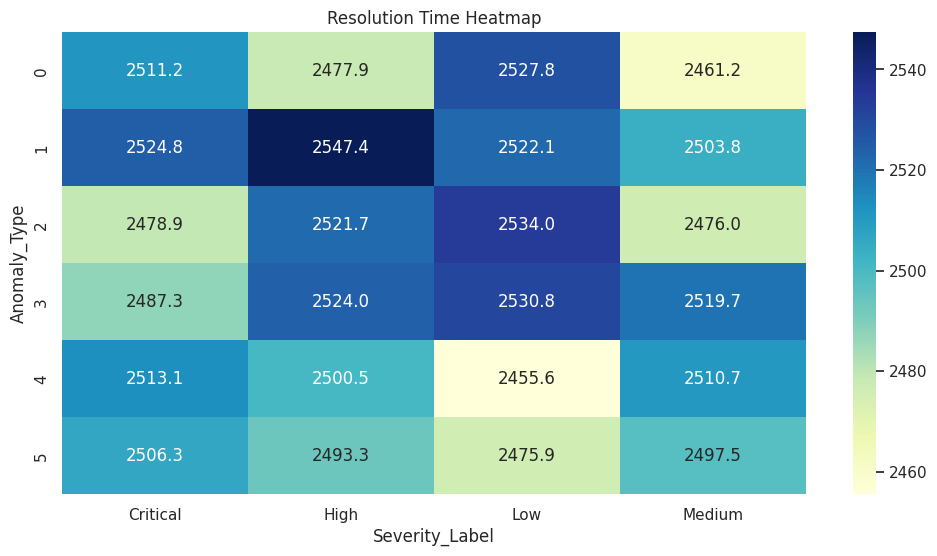

In [32]:
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Resolution Time Heatmap")
plt.show()

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.2535
Decision Tree: 0.2516
Random Forest: 0.2543
Gradient Boosting: 0.2545


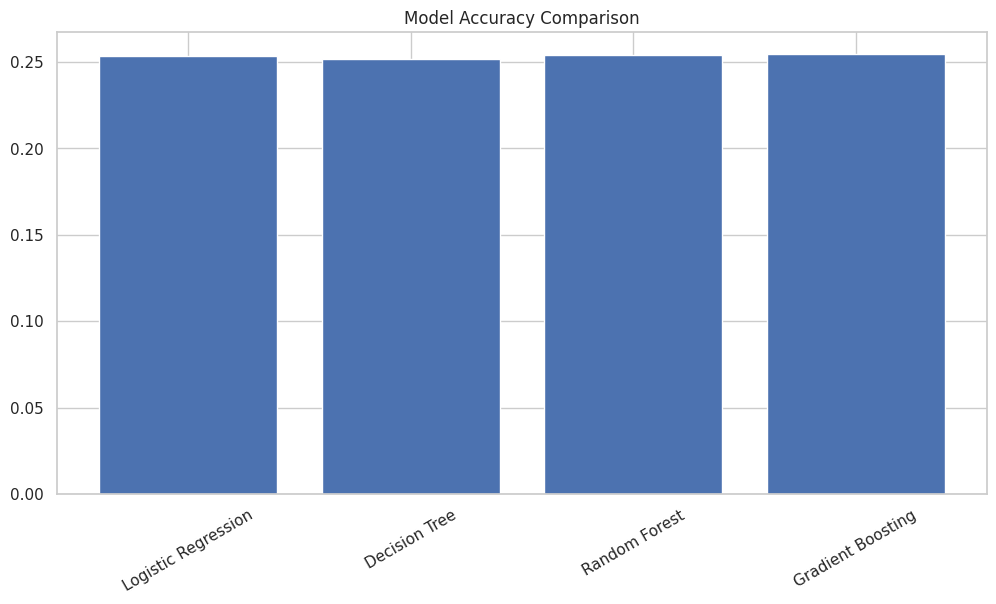

In [34]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

In [35]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
12,Memory_Usage_MB,0.043863
14,Network_In_KB,0.043705
15,Network_Out_KB,0.043676
24,Transaction_ID,0.043650
11,CPU_Usage_Percent,0.043593
13,Disk_Usage_Percent,0.043577
9,Process_ID,0.043542
20,User_ID,0.043532
5,Resolution_Time_min,0.043519
8,Host_IP,0.043504


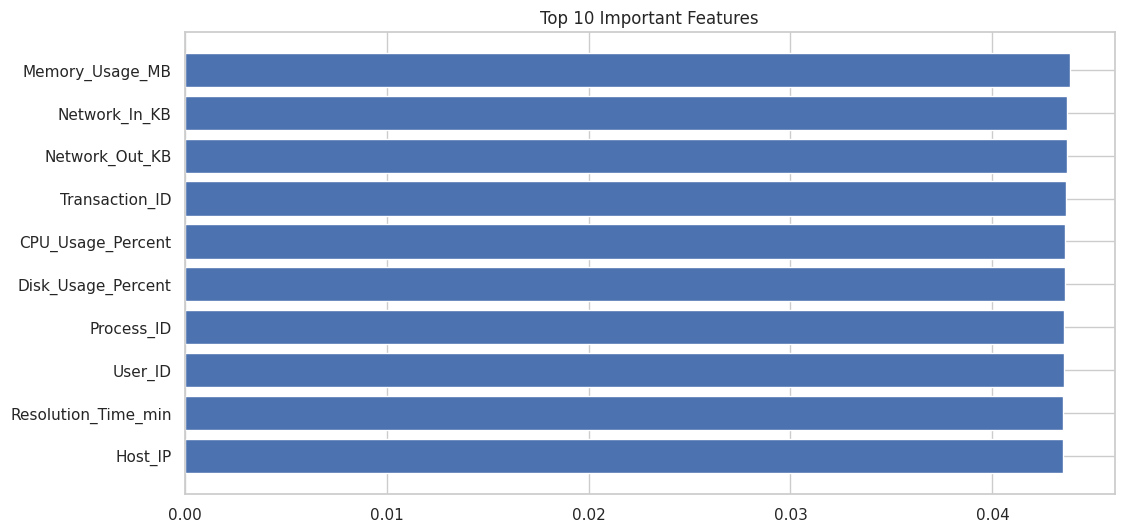

In [36]:
plt.figure()
plt.barh(feat_imp['Feature'][:10], feat_imp['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: 0.2534124692975576


In [38]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Final Accuracy: 0.247
              precision    recall  f1-score   support

           0       0.25      0.28      0.27      5037
           1       0.24      0.24      0.24      4992
           2       0.24      0.24      0.24      4913
           3       0.25      0.23      0.24      5058

    accuracy                           0.25     20000
   macro avg       0.25      0.25      0.25     20000
weighted avg       0.25      0.25      0.25     20000



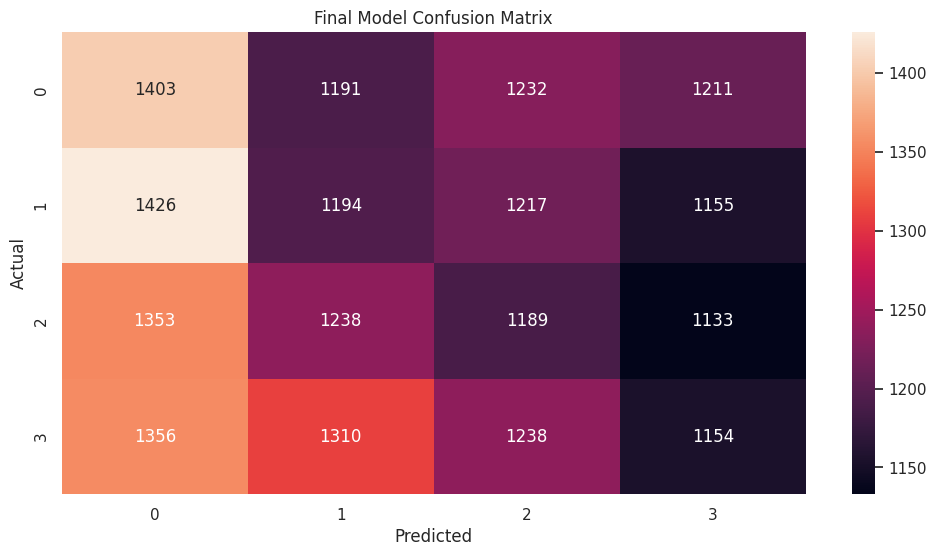

In [39]:
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
!pip install xgboost

In [41]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='mlogloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.251


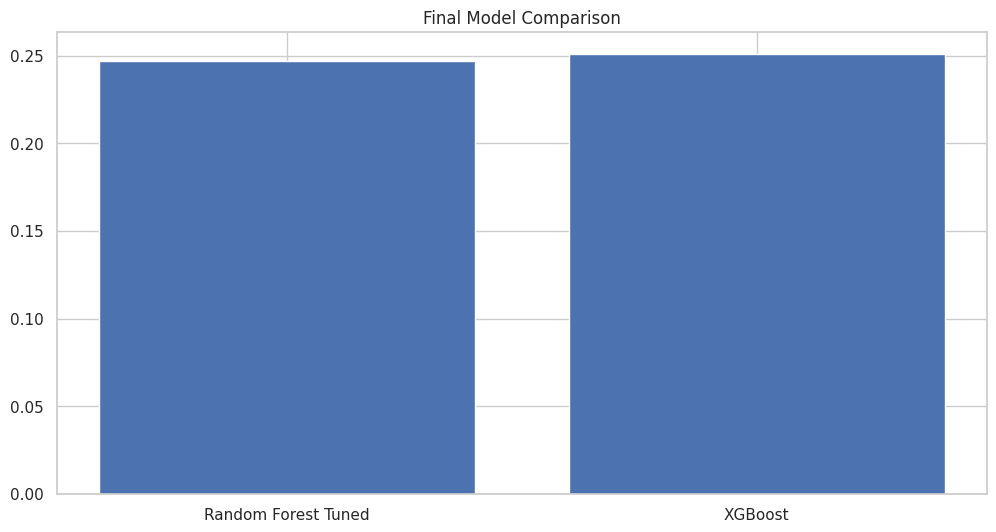

In [42]:
final_results = {
    "Random Forest Tuned": accuracy_score(y_test, y_pred_best),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

plt.figure()
plt.bar(final_results.keys(), final_results.values())
plt.title("Final Model Comparison")
plt.show()